# 10 · Diffusion maps

A UMAP is built to show you **groups**. It pulls neighbours together and pushes
everything else apart, so a smooth gradient tends to come out as a chain of islands.

A diffusion map is built for the opposite case. It treats the neighbour graph as a random
walk between cells and asks which directions that walk explores **slowly** — and a slow
direction is exactly what a continuous transition looks like. Where a UMAP gives you
clusters to name, a diffusion map gives you an axis to order cells along.

[Chapter 09](09_paga.ipynb) has already drawn the shape this axis is trying to flatten:
two routes out of the pluripotent core, not one. Keep that in mind for section 5, where
the ordering comes out clean and the correlation with real time does not.

| | |
|---|---|
| **1** | Compute it, and read the spectrum |
| **2** | Look at the components |
| **3** | The graph decides what you get |
| **4** | Pseudotime, and the root cell that determines it |
| **5** | Check it before you believe it |
| **6** | Does the axis describe the rest of the plate? |

In [3]:
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats

plt.rcParams.update({          # the house style, no package needed
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})

def panel_grid(n, *, ncols=3, size=(3.6, 3.0)):
    """A figure with `n` axes on a grid, the unused ones removed."""
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, squeeze=False,
                             figsize=(size[0] * ncols, size[1] * nrows))
    flat = axes.ravel()
    for ax in flat[n:]:
        ax.remove()
    return fig, flat[:n]
pd.set_option("display.width", 140)

# The tables live here on Euler. Change this line if your copy is elsewhere.
DATA = Path("/cluster/project/mcsliberali/data_mcs_2026")

cells = sc.read_h5ad(DATA / "mcs2026_controls_downstream.h5ad")
identity = [m for m in cells.uns["panels"]["identity"] if m in set(cells.var_names)]
print(f"{cells.n_obs:,} control cells")
print(f"  graph : {cells.obsp['identity_connectivities'].nnz:,} edges, from chapter 07")
print(f"  states: {list(cells.obs.cell_state.cat.categories)}")

97,177 control cells
  graph : 1,885,118 edges, from chapter 07
  states: ['Pluripotent', 'TE-like', 'Hypoblast', 'artefact']


## 1 · Compute it, and read the spectrum

No new distance calculation: a diffusion map is computed **from a neighbour graph you
already have** — the one [chapter 07](07_umap.ipynb) built on the eight identity markers.
Section 3 builds the alternative and shows how much the choice decides.

In [4]:
sc.tl.diffmap(cells, n_comps=15, neighbors_key="identity")
print(f"  X_diffmap: {cells.obsm['X_diffmap'].shape}")

evals = pd.Series(cells.uns["diffmap_evals"], index=[f"DC{i}" for i in range(15)])
evals.round(4).head(8)

  X_diffmap: (97177, 15)


DC0    1.0000
DC1    0.9982
DC2    0.9974
DC3    0.9934
DC4    0.9914
DC5    0.9905
DC6    0.9903
DC7    0.9888
dtype: float32

**DC0 is always exactly 1 and always meaningless** — it is the constant vector, the
statement that a random walk left alone forever ends up everywhere. Scanpy keeps it as
column 0 of `X_diffmap`, so every plot below starts at column 1. Forgetting this is the
most common mistake with diffusion maps, and it produces a plot with one axis that is
pure noise.

What you want from the rest is a **gap**: a few eigenvalues clearly above the others,
after which they flatten. The number above the gap is the number of directions worth
looking at.

  DC1 - DC2 gap: 0.0009
  DC2 - DC3 gap: 0.0040


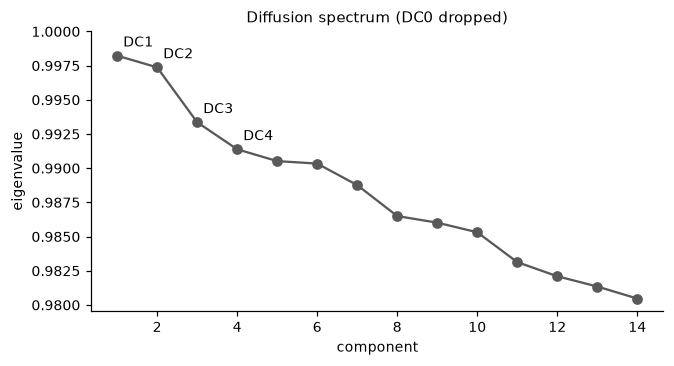

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(range(1, 15), evals.values[1:], marker="o", color="0.35")
ax.set(xlabel="component", ylabel="eigenvalue", title="Diffusion spectrum (DC0 dropped)")
ax.set_ylim(top=1.0)
for i in range(1, 5):
    ax.annotate(f"DC{i}", (i, evals.values[i]), textcoords="offset points",
                xytext=(4, 6), fontsize=9)
fig.tight_layout()

print(f"  DC1 - DC2 gap: {evals.iloc[1] - evals.iloc[2]:.4f}")
print(f"  DC2 - DC3 gap: {evals.iloc[2] - evals.iloc[3]:.4f}")

:::{important}
**There is no gap here, and that is information.** The eigenvalues slide down from 0.99
by thousandths. No small number of components stands out, which says the data is one
continuum rather than a few well-separated branches.

Report that, rather than picking a number of components anyway. A flat spectrum means
"DC1 and DC2 are the two slowest directions", not "there are exactly two things here" —
and any claim of the second kind needs a gap to stand on.
:::

## 2 · Look at the components

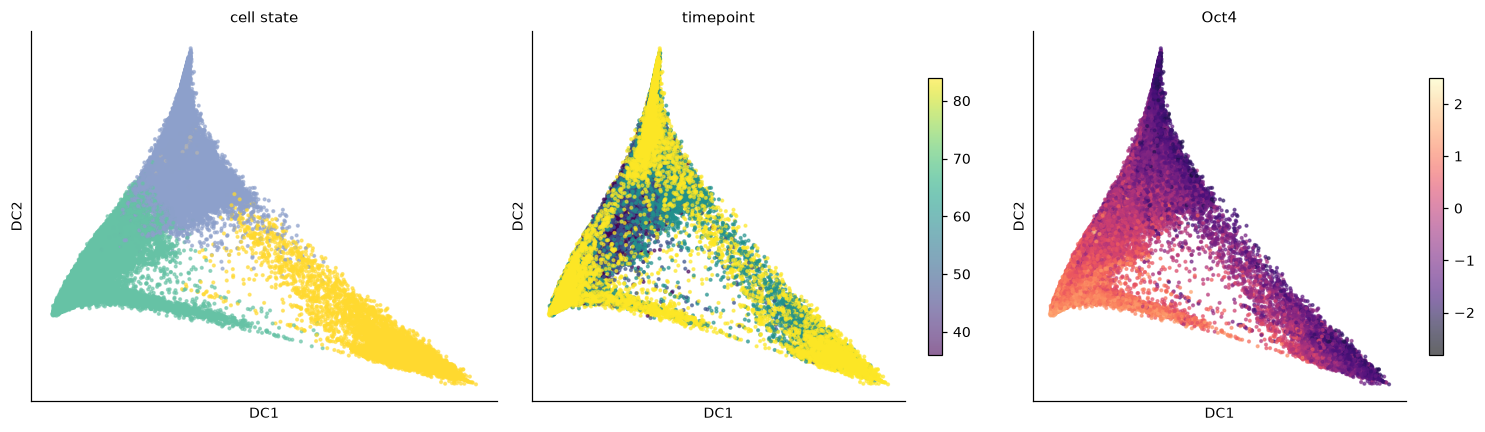

In [6]:
dc = cells.obsm["X_diffmap"]
fig, axes = panel_grid(3, ncols=3, size=(4.6, 4.0))

for ax, (colour, title, kwargs) in zip(axes, [
    (cells.obs.cell_state.cat.codes, "cell state", dict(cmap="Set2")),
    (cells.obs.timepoint_h.astype(int), "timepoint", dict(cmap="viridis")),
    (np.asarray(cells[:, "Oct4"].X).ravel(), "Oct4", dict(cmap="magma")),
]):
    s = ax.scatter(dc[:, 1], dc[:, 2], c=colour, s=3, alpha=0.6, **kwargs)
    ax.set(title=title, xlabel="DC1", ylabel="DC2", xticks=[], yticks=[])
    if title != "cell state":
        fig.colorbar(s, ax=ax, shrink=0.75)
fig.tight_layout()

In [7]:
oct4 = np.asarray(cells[:, "Oct4"].X).ravel()
pd.DataFrame({
    "Spearman vs DC1": {
        "Oct4":      stats.spearmanr(dc[:, 1], oct4).statistic,
        "GATA4":     stats.spearmanr(dc[:, 1], np.asarray(cells[:, "GATA4"].X).ravel()).statistic,
        "PC1":       stats.spearmanr(dc[:, 1], cells.obsm["X_pca"][:, 0]).statistic,
        "DAPI":      stats.spearmanr(dc[:, 1], cells.obs.dapi).statistic,
        "timepoint": stats.spearmanr(dc[:, 1], cells.obs.timepoint_h.astype(int)).statistic,
    }
}).round(3)

,Spearman vs DC1
Oct4,-0.849
GATA4,0.288
PC1,-0.659
DAPI,-0.514
timepoint,-0.029


Do this for every axis you intend to interpret. DC1 tracks Oct4 strongly — it is a
pluripotency axis, which is what you would hope for from a graph built on lineage
markers. It is only weakly related to overall brightness, and barely related to time.

:::{note}
**Read the magnitude; the sign is arbitrary.** An eigenvector multiplied by −1 is the
same eigenvector, so which end of DC1 comes out positive depends on the numerical
solver, not on the data — and it can flip between runs on the same input. The same is
true of PCA loadings.

This matters more than it sounds, because it makes `argmax` along a component an unsafe
way to pick anything. Section 4 needs an extreme cell, and picks it by a marker instead.
:::

## 3 · The graph decides what you get

Nothing above was a property of "the diffusion map". Build the graph
[chapter 07](07_umap.ipynb) decided against — the PCA of all 38 markers — run exactly the
same call on it, and see what changes.

In [8]:
alt = cells.copy()
sc.pp.pca(alt, n_comps=20, random_state=0)         # the road not taken, from chapter 06
sc.pp.neighbors(alt, n_neighbors=15, n_pcs=15, random_state=0)
sc.tl.diffmap(alt, n_comps=10)
alt_dc = alt.obsm["X_diffmap"]

comparison = pd.DataFrame({
    "identity graph (8 markers)": {
        "Oct4": stats.spearmanr(dc[:, 1], np.asarray(cells[:, "Oct4"].X).ravel()).statistic,
        "PC1 — overall brightness": stats.spearmanr(dc[:, 1], cells.obsm["X_pca"][:, 0]).statistic,
    },
    "PCA graph (all 38 markers)": {
        "Oct4": stats.spearmanr(alt_dc[:, 1], np.asarray(alt[:, "Oct4"].X).ravel()).statistic,
        "PC1 — overall brightness": stats.spearmanr(alt_dc[:, 1], alt.obsm["X_pca"][:, 0]).statistic,
    },
}).round(3)
comparison.index.name = "|Spearman| of DC1 vs"
comparison.abs()

/cluster/home/maaraujo/venvs/mcs2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,identity graph (8 markers),PCA graph (all 38 markers)
|Spearman| of DC1 vs,,
Oct4,0.849,0.769
PC1 — overall brightness,0.659,0.868


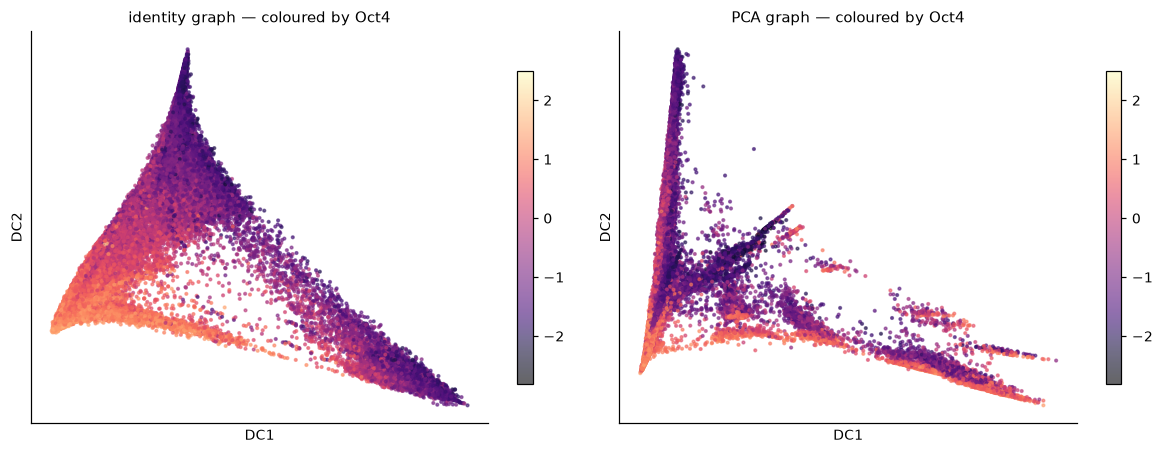

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (coords, label) in zip(axes, [(dc, "identity graph"), (alt_dc, "PCA graph")]):
    s = ax.scatter(coords[:, 1], coords[:, 2], c=np.asarray(cells[:, "Oct4"].X).ravel(),
                   cmap="magma", s=3, alpha=0.6)
    ax.set(title=f"{label} — coloured by Oct4", xlabel="DC1", ylabel="DC2",
           xticks=[], yticks=[])
    fig.colorbar(s, ax=ax, shrink=0.8)
fig.tight_layout()

:::{warning}
**Same algorithm, same cells, different meaning.** On the identity graph DC1 is a
pluripotency axis. On the 38-marker graph it is largely
[PC1](06_pca.ipynb) — how brightly the cell stained. Chapter 07 rejected that graph on a
batch-effect argument; here is the same choice arriving from the other direction.

Neither is a mistake. A diffusion map has no opinion about what should matter; it
inherits that entirely from the graph you hand it. Which is why a methods section has to
say **what the graph was built on**, and why "we ran a diffusion map" is not a
description of anything.
:::

## 4 · Pseudotime, and the root cell that determines it

Diffusion pseudotime turns the axis into a number per cell: the diffusion distance from a
**root cell** you choose. Everything about the result follows from that choice, so make
it deliberately and write it down.

The defensible root here is a cell as close to the starting state as the data allows:
**pluripotent, at the earliest timepoint, with the most Oct4**.

Every one of those three conditions comes from knowing what was put in the wells. None
comes from the diffusion map — picking "the cell at the end of DC1" would be circular,
and, since the sign of DC1 is arbitrary, would silently choose the opposite end on a
rerun.

In [10]:
candidates = np.where((cells.obs.cell_state.astype(str) == "Pluripotent")
                      & (cells.obs.timepoint_h.astype(int) == 36))[0]
root = int(candidates[np.argmax(oct4[candidates])])
cells.uns["iroot"] = root

print(f"  {len(candidates)} candidate cells (pluripotent, 36 h)")
print(f"  root: cell {root}, well {cells.obs.well.iloc[root]}, "
      f"Oct4 {oct4[root]:+.2f} SDs (max of the candidates)")

  6927 candidate cells (pluripotent, 36 h)
  root: cell 63750, well M04, Oct4 +1.42 SDs (max of the candidates)


In [11]:
sc.tl.dpt(cells, neighbors_key="identity")
pseudotime = cells.obs.dpt_pseudotime.values
print(f"  pseudotime: {np.isfinite(pseudotime).sum():,} of {len(pseudotime):,} cells finite, "
      f"range {pseudotime.min():.2f} to {pseudotime.max():.2f}")

  pseudotime: 97,177 of 97,177 cells finite, range 0.00 to 1.00


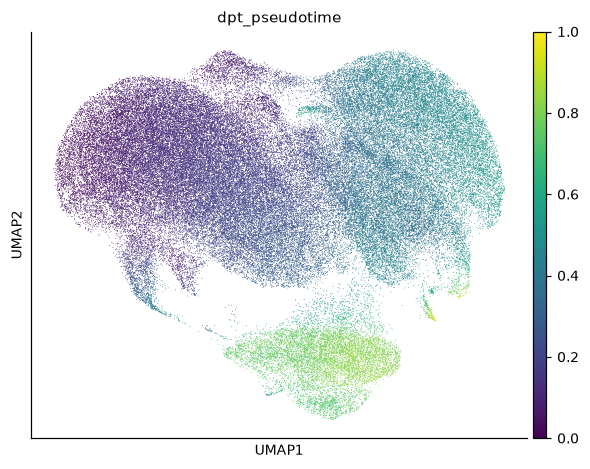

In [19]:
sc.pl.umap(cells, color=["dpt_pseudotime"])

:::{warning}
**Pseudotime is not time.** It is a distance in a graph, expressed on an arbitrary scale
from an arbitrary origin. Two things follow:

- **It has no units and no zero.** A cell at 0.4 is not "twice as far along" as one at
  0.2, and 0.4 in this notebook means nothing in anyone else's.
- **Change the root and every number changes.** Choose a root in the wrong cluster and
  you get a smooth, plausible, entirely backwards ordering. Nothing in the output will
  tell you.
:::

## 5 · Check it before you believe it

A pseudotime always produces numbers. Two checks that it produces *meaningful* ones, and
both use information the algorithm never saw.

**Does it order the cell states the way the biology says?** Pluripotent cells should sit
near the root; differentiated ones further away.

In [12]:
by_state = pd.DataFrame({"pseudotime": pseudotime,
                         "state": cells.obs.cell_state.astype(str)})
by_state.groupby("state").pseudotime.describe()[["count", "25%", "50%", "75%"]].round(3)

,count,25%,50%,75%
state,,,,
Hypoblast,9906.0,0.717,0.768,0.805
Pluripotent,54747.0,0.094,0.141,0.197
TE-like,32055.0,0.366,0.415,0.454
artefact,469.0,0.660,0.754,0.817


**Does it move with the clock?** The cells were fixed at four known times. Pseudotime was
built without that column, so any agreement is real evidence — and disagreement is worth
just as much to know.

  Spearman(pseudotime, hours) = +0.087

         25%    50%    75%
hours                     
36     0.156  0.234  0.319
48     0.136  0.239  0.362
60     0.130  0.271  0.430
84     0.125  0.230  0.467


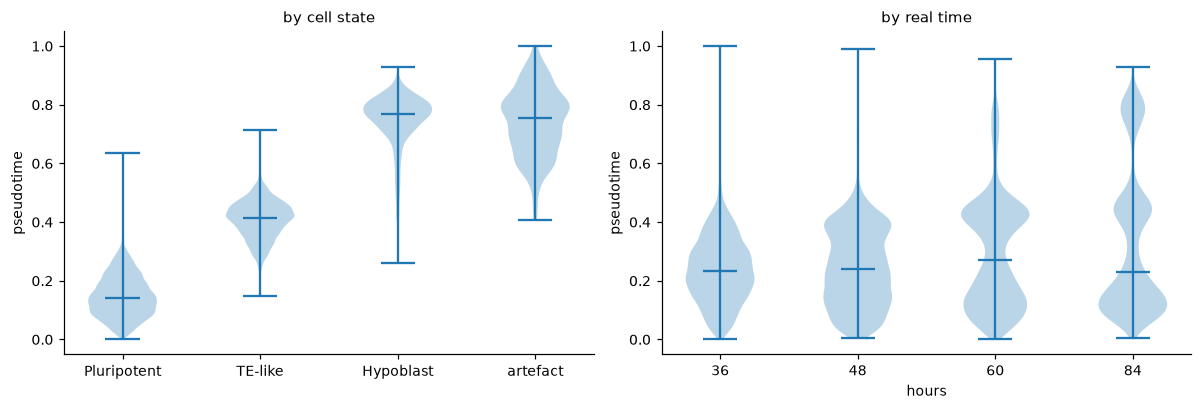

In [13]:
by_time = pd.DataFrame({"pseudotime": pseudotime,
                        "hours": cells.obs.timepoint_h.astype(int)})
print(f"  Spearman(pseudotime, hours) = {stats.spearmanr(pseudotime, by_time.hours).statistic:+.3f}\n")
print(by_time.groupby("hours").pseudotime.describe()[["25%", "50%", "75%"]].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].violinplot([by_state.pseudotime[by_state.state == s].values
                    for s in cells.obs.cell_state.cat.categories], showmedians=True)
axes[0].set(xticks=range(1, len(cells.obs.cell_state.cat.categories) + 1),
            xticklabels=list(cells.obs.cell_state.cat.categories),
            ylabel="pseudotime", title="by cell state")

hours = sorted(by_time.hours.unique())
axes[1].violinplot([by_time.pseudotime[by_time.hours == h].values for h in hours],
                   showmedians=True)
axes[1].set(xticks=range(1, len(hours) + 1), xticklabels=hours,
            xlabel="hours", ylabel="pseudotime", title="by real time")
fig.tight_layout()

The medians rise with real time, and the pluripotent cells sit lowest — so the ordering
is not arbitrary. But the correlation with the clock is weak and the distributions
overlap almost completely, which says something worth saying out loud: **most of what
separates these cells is not time.** At any one timepoint the culture contains cells all
along the axis.

That is a statement about the axis, not about any treatment. What the perturbations do to
it is a different question, and one the analysis in
[Part 4](../../part4_final_solutions/intro.md) takes up.

## 6 · Does the axis describe the rest of the plate?

Everything above was built from untreated cells, which settles one worry before it can be
raised: the axis cannot be an artefact of the perturbations, because there were none.

It raises the opposite worry instead. An axis fitted on 32 control wells is only useful to
[Part 4](../../part4_final_solutions/intro.md) if it still means the same thing on the
other 192 — and there is no reason in principle that it must. Compounds can push cells
somewhere the controls never go.

The test: build the same diffusion map on a geosketch of all eighteen conditions and see
whether DC1 comes out describing the same thing.

In [14]:
plate = sc.read_h5ad(DATA / "mcs2026_sketch.h5ad")
plate.obsm["X_identity"] = np.asarray(plate[:, identity].X)
sc.pp.neighbors(plate, n_neighbors=15, use_rep="X_identity", random_state=0)
sc.tl.diffmap(plate, n_comps=10)

plate_dc = plate.obsm["X_diffmap"]
plate_oct4 = np.asarray(plate[:, "Oct4"].X).ravel()
print(f"  controls   : {cells.n_obs:,} cells, 2 conditions")
print(f"  whole plate: {plate.n_obs:,} sketched cells, {plate.obs.condition.nunique()} conditions")

  controls   : 97,177 cells, 2 conditions
  whole plate: 30,000 sketched cells, 18 conditions


### Does DC1 still mean the same thing?

Signs are arbitrary, so compare magnitudes.

In [15]:
pd.DataFrame({
    "controls only": {
        "|Spearman| DC1 vs Oct4": abs(stats.spearmanr(dc[:, 1], oct4).statistic),
        "cells": cells.n_obs,
    },
    "all 18 conditions": {
        "|Spearman| DC1 vs Oct4": abs(stats.spearmanr(plate_dc[:, 1], plate_oct4).statistic),
        "cells": plate.n_obs,
    },
}).round(3)

,controls only,all 18 conditions
|Spearman| DC1 vs Oct4,0.849,0.873
cells,97177.000,30000.000


**The axis survives.** DC1 tracks Oct4 just as strongly when the sixteen compounds are in
the data as when they are not — so a pluripotency coordinate learned on the controls is a
pluripotency coordinate everywhere, and Part 4 can measure perturbations *against* it.

That is the general shape of what this stage has been doing. A method learned somewhere
with no treatments is only worth anything if it transfers, and "does it transfer?" is a
question with a number attached, not a matter of hoping.

### One last check: the negative result, properly powered

[Chapter 07](07_umap.ipynb) found the two controls interleaved in the embedding. Ask the
same question of the pseudotime — and then ask whether the test could have answered it.

In [16]:
per_well = pd.DataFrame({
    "pseudotime": cells.obs.dpt_pseudotime.values,
    "condition": cells.obs.condition.astype(str).values,
    "well": cells.obs.well.astype(str).values,
}).groupby(["condition", "well"]).pseudotime.mean().reset_index()

pbs = per_well.loc[per_well.condition == "PBS", "pseudotime"]
dmso = per_well.loc[per_well.condition == "DMSO", "pseudotime"]
print(f"  PBS  {pbs.mean():.3f} over {len(pbs)} wells")
print(f"  DMSO {dmso.mean():.3f} over {len(dmso)} wells")
print(f"  p       = {stats.mannwhitneyu(pbs, dmso).pvalue:.3f}")
print(f"  p_floor = {2 / comb(len(pbs) + len(dmso), len(pbs)):.2e}")

  PBS  0.273 over 12 wells
  DMSO 0.283 over 20 wells
  p       = 0.340
  p_floor = 8.86e-09


:::{important}
**This is what a trustworthy negative result looks like.** The floor is $9\times10^{-9}$,
so the design had room to return a p-value eight orders of magnitude smaller than the
conventional threshold — and it returned a number nowhere near it.

Compare that with a per-timepoint comparison of three wells against five, where the floor
is 0.0357 and "not significant" can only ever mean "this experiment could not have told
you". Both report a null; only one of them is evidence of absence.

**Always print the floor next to a negative result.** It is the difference between "we
looked and there was nothing" and "we did not look hard enough to know".
:::

## 7 · Save

In [17]:
cells.write_h5ad(DATA / "mcs2026_controls_downstream.h5ad", compression="gzip")
print(f"  obsm : {list(cells.obsm)}")
print(f"  obs  : cell_state, dpt_pseudotime, cluster, leiden_*")
print(f"  uns  : iroot = {cells.uns['iroot']}")

  obsm : ['X_identity', 'X_pca', 'X_umap', 'X_diffmap']
  obs  : cell_state, dpt_pseudotime, cluster, leiden_*
  uns  : iroot = 63750


## Stage 2 complete

| | |
|---|---|
| [05](05_the_anndata_object.ipynb) | which slot holds what, and which file to open |
| [06](06_pca.ipynb) | the axes of largest variation, and what the first one is made of |
| [07](07_umap.ipynb) | a picture, what it does not mean, and what it does on two conditions that should match |
| [08](08_cell_type_annotation.ipynb) | clusters, names, and the labels carried back to every cell |
| [09](10_diffusion_map.ipynb) | a continuous axis, the root that defines it, and a null result you can trust |

Two of those chapters ran the pipeline on **DMSO and PBS alone**, and between them they
settled three things no amount of reasoning could have:

| | |
|---|---|
| the embedding does not invent a difference | condition purity 1.1× chance |
| there is no plate-position effect | row purity 1.0× chance, once same-well pairs are excluded |
| the differentiation axis is not made by the drugs | DC1 tracks Oct4 at 0.81 with or without them |

And one thing that changes how you analyse everything else: **cells from the same well
neighbour each other 2.2× more often than chance**, in untreated wells, within a single
timepoint. That is why every test counts wells.

You now have every technique the analysis needs, and you have applied none of them to a
question. That is next: [Your turn](../11_your_turn.ipynb).

---

## Exercises

### 1. Move the root

Recompute the pseudotime from a root in the hypoblast cluster instead. What happens to
the ordering, and how would you have known it was wrong if you had not chosen the first
root yourself?

:::{admonition} Solution
:class: dropdown

```python
alt = cells.copy()
hypo = np.where(alt.obs.cell_state.astype(str) == "Hypoblast")[0]
alt.uns["iroot"] = int(hypo[np.argmin(dc[hypo, 1])])
sc.tl.dpt(alt)
print(pd.DataFrame({"pt": alt.obs.dpt_pseudotime.values,
                    "state": alt.obs.cell_state.astype(str)})
      .groupby("state").pt.median().round(3))
```

The ordering reverses, and the output is exactly as smooth and as convincing as before.
Nothing in the pseudotime itself flags it.

The only defence is external: pluripotent cells at 36 hours are the starting state
because of what was put in the wells, not because of anything in the matrix. State the
root and the reason for it in your methods, every time.
:::

### 2. Does DC2 mean anything?

DC1 tracks Oct4. Correlate DC2 with every one of the 38 markers and see whether it has an
interpretation of its own, or is a second axis of the same thing.

:::{admonition} Solution
:class: dropdown

```python
X = np.asarray(cells.X)
rho = pd.Series([stats.spearmanr(dc[:, 2], X[:, i]).statistic
                 for i in range(cells.n_vars)], index=cells.var_names)
print(rho.reindex(rho.abs().sort_values(ascending=False).index).head(8).round(3))
```

Read it the way you read the PCA loadings in [chapter 06](06_pca.ipynb): if the top
correlations are all the same lineage, DC2 is a second differentiation axis; if they are
a mixture with no theme, it is structure the graph found and you cannot name — which is
a reason not to build an argument on it.
:::

### 3. A diffusion map of a discrete dataset

Diffusion maps assume continuity. Build one on a dataset that is genuinely discrete —
take only the pluripotent and hypoblast cells, dropping the intermediates — and look at
the spectrum. Does the gap you could not find above appear?

:::{admonition} Solution
:class: dropdown

```python
ends = cells[cells.obs.cell_state.isin(["Pluripotent", "Hypoblast"])].copy()
sc.pp.neighbors(ends, n_neighbors=15, use_rep="X_identity", random_state=0)
sc.tl.diffmap(ends, n_comps=10)
print(np.round(ends.uns["diffmap_evals"], 4))
```

Removing the middle of a continuum manufactures a gap, and the spectrum duly reports one.
That is the honest reading of this exercise: a spectral gap tells you the graph has
separated components, and a graph can be separated because the biology is, or because you
filtered it that way. The algorithm cannot tell the two apart, and neither can a reader
who is not told what was excluded.
:::

---

**Next:** [Your turn](../11_your_turn.ipynb).